# 04 — Compléments théoriques & Hawkes

Two topics from the MODAL v2 document:

**Part A (Section 2.1):** Why the probability of reaching zero differs between the discrete birth-death process and its Brownian limit.

**Part B (Section 1.2.4):** Non-independent first limits via Hawkes processes — single queue, then two coupled queues.

---

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
from model.Hawkes import *
from model.hitting_times import batch_hitting_times

plt.rcParams.update({'figure.figsize': (12, 4), 'font.size': 11,
                      'axes.grid': True, 'grid.alpha': 0.3})

---
# Part A — Discrete vs Brownian hitting probability (Section 2.1)

A birth-death process $X_t$ on $\mathbb{Z}$: $+1$ at rate $\lambda^+$, $-1$ at rate $\lambda^-$, starting at $X_0 = a > 0$.

**Discrete (exact):**
$$P_{\text{discret}} = \begin{cases} 1 & \text{if } \rho \geq 1 \\ \rho^a & \text{if } \rho < 1 \end{cases}, \quad \rho = \lambda^- / \lambda^+$$

**Brownian approximation:**
$$P_{\text{BM}} = \begin{cases} 1 & \text{if } \mu \leq 0 \\ \exp\!\left(-\frac{2\mu a}{\sigma^2}\right) & \text{if } \mu > 0 \end{cases}, \quad \mu = \lambda^+ - \lambda^-, \; \sigma^2 = \lambda^+ + \lambda^-$$

They agree when $\mu \leq 0$ but **disagree** when $\mu > 0$: same exponential decay in $a$, but with different rates.

In [2]:
# ── Case 1: μ < 0 (our MODAL case: λ⁺=1.2, λ⁻=1.5) ─────────────
print('Case 1: λ⁺ = 1.2, λ⁻ = 1.5  (μ = -0.3 < 0)')
print(f'{"a":>4s}  {"P_discrete":>12s}  {"P_BM":>12s}  {"Match?":>8s}')
print('─' * 42)
for a in [1, 5, 10, 20, 50]:
    pd = prob_reach_zero_discrete(a, 1.2, 1.5)
    pb = prob_reach_zero_brownian(a, 1.2, 1.5)
    print(f'{a:4d}  {pd:12.6f}  {pb:12.6f}  {"✓":>8s}')
print('→ Both = 1 always. Perfect agreement when μ ≤ 0.')

Case 1: λ⁺ = 1.2, λ⁻ = 1.5  (μ = -0.3 < 0)
   a    P_discrete          P_BM    Match?
──────────────────────────────────────────
   1      1.000000      1.000000         ✓
   5      1.000000      1.000000         ✓
  10      1.000000      1.000000         ✓
  20      1.000000      1.000000         ✓
  50      1.000000      1.000000         ✓
→ Both = 1 always. Perfect agreement when μ ≤ 0.


In [3]:
# ── Case 2: μ > 0 (λ⁺=1.5, λ⁻=1.2 → drift upward) ──────────────
print('Case 2: λ⁺ = 1.5, λ⁻ = 1.2  (μ = +0.3 > 0)')
print(f'{"a":>4s}  {"P_discrete":>12s}  {"P_BM":>12s}  {"Rel.err":>10s}')
print('─' * 44)
for a in [1, 2, 5, 10, 20, 50]:
    pd = prob_reach_zero_discrete(a, 1.5, 1.2)
    pb = prob_reach_zero_brownian(a, 1.5, 1.2)
    err = abs(pd - pb) / pd * 100 if pd > 1e-12 else 0
    print(f'{a:4d}  {pd:12.8f}  {pb:12.8f}  {err:9.2f}%')
print('→ Same exponential shape, but different decay rates!')

Case 2: λ⁺ = 1.5, λ⁻ = 1.2  (μ = +0.3 > 0)
   a    P_discrete          P_BM     Rel.err
────────────────────────────────────────────
   1    0.80000000    0.80073740       0.09%
   2    0.64000000    0.64118039       0.18%
   5    0.32768000    0.32919299       0.46%
  10    0.10737418    0.10836802       0.93%
  20    0.01152922    0.01174363       1.86%
  50    0.00001427    0.00001495       4.71%
→ Same exponential shape, but different decay rates!


In [4]:
""" # ── Verify with Monte Carlo simulation ────────────────────────────
# Simulate the discrete process and count how often it reaches 0
lp_test, lm_test = 1.5, 1.2
rng = np.random.default_rng(42)
T_max_sim = 500  # time limit for each run

a_values = np.arange(1, 26)
p_sim = []
N_mc = 5000

for a in a_values:
    n_hit = 0
    for _ in range(N_mc):
        x = int(a)
        t = 0
        while x > 0 and t < T_max_sim:
            dt = rng.exponential(1.0 / (lp_test + lm_test))
            t += dt
            x += 1 if rng.random() < lp_test / (lp_test + lm_test) else -1
        if x <= 0:
            n_hit += 1
    p_sim.append(n_hit / N_mc)

p_sim = np.array(p_sim)
p_disc = np.array([prob_reach_zero_discrete(int(a), lp_test, lm_test) for a in a_values])
p_bm = np.array([prob_reach_zero_brownian(float(a), lp_test, lm_test) for a in a_values]) """

' # ── Verify with Monte Carlo simulation ────────────────────────────\n# Simulate the discrete process and count how often it reaches 0\nlp_test, lm_test = 1.5, 1.2\nrng = np.random.default_rng(42)\nT_max_sim = 500  # time limit for each run\n\na_values = np.arange(1, 26)\np_sim = []\nN_mc = 5000\n\nfor a in a_values:\n    n_hit = 0\n    for _ in range(N_mc):\n        x = int(a)\n        t = 0\n        while x > 0 and t < T_max_sim:\n            dt = rng.exponential(1.0 / (lp_test + lm_test))\n            t += dt\n            x += 1 if rng.random() < lp_test / (lp_test + lm_test) else -1\n        if x <= 0:\n            n_hit += 1\n    p_sim.append(n_hit / N_mc)\n\np_sim = np.array(p_sim)\np_disc = np.array([prob_reach_zero_discrete(int(a), lp_test, lm_test) for a in a_values])\np_bm = np.array([prob_reach_zero_brownian(float(a), lp_test, lm_test) for a in a_values]) '

In [5]:
""" fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: probabilities
ax = axes[0]
ax.plot(a_values, p_disc, 'o-', ms=4, lw=1.5, color='C0', label='Discrete: $\\rho^a$')
ax.plot(a_values, p_bm, 's--', ms=4, lw=1.5, color='C3', label='BM: $e^{-2\\mu a/\\sigma^2}$')
ax.plot(a_values, p_sim, '^', ms=5, color='C2', alpha=0.7, label=f'MC simulation (N={N_mc})')
ax.set_xlabel('Initial position $a$')
ax.set_ylabel('$P$(reach 0)')
ax.set_title(f'$\\lambda^+ = {lp_test}$, $\\lambda^- = {lm_test}$ ($\\mu > 0$)')
ax.legend(fontsize=9)

# Middle: log scale
ax = axes[1]
ax.semilogy(a_values, p_disc, 'o-', ms=4, lw=1.5, color='C0', label='Discrete')
ax.semilogy(a_values, p_bm, 's--', ms=4, lw=1.5, color='C3', label='Brownian')
ax.semilogy(a_values, np.clip(p_sim, 1e-4, 1), '^', ms=5, color='C2', alpha=0.7, label='MC')
ax.set_xlabel('$a$')
ax.set_ylabel('$P$(reach 0) — log scale')
ax.set_title('Log scale: different slopes = different rates')
ax.legend(fontsize=9)

# Right: the two decay rates
ax = axes[2]
rho = lm_test / lp_test
mu = lp_test - lm_test
sig2 = lp_test + lm_test
rate_disc = -np.log(rho)
rate_bm = 2 * mu / sig2

rates = [rate_disc, rate_bm]
colors = ['C0', 'C3']
labels = [f'Discrete: $-\\ln\\rho = {rate_disc:.4f}$',
          f'BM: $2\\mu/\\sigma^2 = {rate_bm:.4f}$']
ax.bar([0, 1], rates, color=colors, width=0.5, edgecolor='white')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Discrete', 'Brownian'])
ax.set_ylabel('Exponential decay rate')
ax.set_title(f'$-\\ln P / a$ as $a \\to \\infty$')
for k in range(2):
    ax.text(k, rates[k] + 0.002, f'{rates[k]:.4f}', ha='center', fontsize=11, fontweight=500)

plt.tight_layout()
plt.show()

print(f'Decay rate discrete: -ln(ρ) = -ln({rho}) = {rate_disc:.6f}')
print(f'Decay rate BM:       2μ/σ²  = 2·{mu}/{sig2} = {rate_bm:.6f}')
print(f'Ratio: {rate_bm/rate_disc:.4f} (would be 1.0 if they matched)') """

" fig, axes = plt.subplots(1, 3, figsize=(16, 5))\n\n# Left: probabilities\nax = axes[0]\nax.plot(a_values, p_disc, 'o-', ms=4, lw=1.5, color='C0', label='Discrete: $\\rho^a$')\nax.plot(a_values, p_bm, 's--', ms=4, lw=1.5, color='C3', label='BM: $e^{-2\\mu a/\\sigma^2}$')\nax.plot(a_values, p_sim, '^', ms=5, color='C2', alpha=0.7, label=f'MC simulation (N={N_mc})')\nax.set_xlabel('Initial position $a$')\nax.set_ylabel('$P$(reach 0)')\nax.set_title(f'$\\lambda^+ = {lp_test}$, $\\lambda^- = {lm_test}$ ($\\mu > 0$)')\nax.legend(fontsize=9)\n\n# Middle: log scale\nax = axes[1]\nax.semilogy(a_values, p_disc, 'o-', ms=4, lw=1.5, color='C0', label='Discrete')\nax.semilogy(a_values, p_bm, 's--', ms=4, lw=1.5, color='C3', label='Brownian')\nax.semilogy(a_values, np.clip(p_sim, 1e-4, 1), '^', ms=5, color='C2', alpha=0.7, label='MC')\nax.set_xlabel('$a$')\nax.set_ylabel('$P$(reach 0) — log scale')\nax.set_title('Log scale: different slopes = different rates')\nax.legend(fontsize=9)\n\n# Right: th

### Why do they differ?

The discrete process lives on $\mathbb{Z}$: it **must** step through integers to reach exactly 0.  
The Brownian motion is continuous: it can "just touch" 0 and bounce back.

The two decay rates are:
$$-\ln\rho = -\ln\frac{\lambda^-}{\lambda^+} \quad \text{vs} \quad \frac{2\mu}{\sigma^2} = \frac{2(\lambda^+-\lambda^-)}{\lambda^++\lambda^-}$$

A Taylor expansion for $\lambda^- = \lambda^+ - \varepsilon$ (small drift) shows they agree at first order in $\varepsilon$ but differ at $O(\varepsilon^2)$. The BM approximation ignores the **lattice structure** of the state space.

**Conclusion for our project:** When $\mu \leq 0$ (our MODAL setting), both give $P = 1$, so the BM approximation is valid for hitting times. When $\mu > 0$, use the exact discrete formula $\rho^a$.

---
# Part B — Hawkes Process Queues (Section 1.2.4)

## B.1 The Hawkes model

Birth rate is constant: $\lambda^+(t) = \mu^+$.

Death rate is a **self-excited and mutually-excited Hawkes process**:
$$\lambda^-(t) = \mu^- + \int_{-\infty}^t \alpha e^{-\beta(t-s)} dN^+_s - \int_{-\infty}^t \alpha e^{-\beta(t-s)} dN^-_s$$

**Interpretation:** Each addition to the queue raises $\lambda^-$ by $\alpha$ (encouraging subsequent removals). Each removal lowers $\lambda^-$ by $\alpha$. Both effects decay exponentially at rate $\beta$.

If the opposite queue is constant, this is equivalent to having $\lambda^-$ depend on the **imbalance** — it's a dynamic version of Model II$^b$ from the paper.

In [6]:
# ── Parameters ────────────────────────────────────────────────────
MU_PLUS = 1.2
MU_MINUS = 1.5   # same as MODAL base case
ALPHA = 0.3
BETA = 0.5

ratio = ALPHA / BETA
m_theo = hawkes_stationary_intensity(MU_PLUS, MU_MINUS, ALPHA, BETA)

print(f'Parameters: μ⁺={MU_PLUS}, μ⁻={MU_MINUS}, α={ALPHA}, β={BETA}')
print(f'α/β = {ratio:.2f} {"< 1 ✓ stationary" if ratio < 1 else "≥ 1 ✗"}')
print(f'\nStationary intensity: m⁻ = (μ⁻ + (α/β)μ⁺) / (1 + α/β)')
print(f'  = ({MU_MINUS} + {ratio}×{MU_PLUS}) / (1 + {ratio})')
print(f'  = {MU_MINUS + ratio*MU_PLUS:.3f} / {1+ratio:.2f} = {m_theo:.4f}')
print(f'\nEffective drift: μ⁺ - m⁻ = {MU_PLUS} - {m_theo:.4f} = {MU_PLUS - m_theo:.4f}')

Parameters: μ⁺=1.2, μ⁻=1.5, α=0.3, β=0.5
α/β = 0.60 < 1 ✓ stationary

Stationary intensity: m⁻ = (μ⁻ + (α/β)μ⁺) / (1 + α/β)
  = (1.5 + 0.6×1.2) / (1 + 0.6)
  = 2.220 / 1.60 = 1.3875

Effective drift: μ⁺ - m⁻ = 1.2 - 1.3875 = -0.1875


## B.2 Question 1.2.4.1 — Simulate a single Hawkes queue

Simulate $\lambda^-(t)$ and estimate the stationary mean $\hat{\bar{\lambda}}^-$.

In [ ]:
# ── Single long simulation (no stop at zero) ─────────────────────
rng = np.random.default_rng(42)
res_single = simulate_hawkes_queue(
    q_init=50, mu_plus=MU_PLUS, mu_minus=MU_MINUS,
    alpha=ALPHA, beta=BETA, T_max=2000.0,
    rng=rng, stop_at_zero=True)

print(f'Simulation: {len(res_single.times)} events in {res_single.times[-1]:.0f}ms')
half = len(res_single.lambda_minus_path) // 2
lam_mean = res_single.lambda_minus_path[half:].mean()
print(f'Mean λ⁻ (second half): {lam_mean:.4f}')
print(f'Theory:                {m_theo:.4f}')

Simulation: 4847 events in 2000ms
Mean λ⁻ (second half): 1.3854
Theory:                1.3875


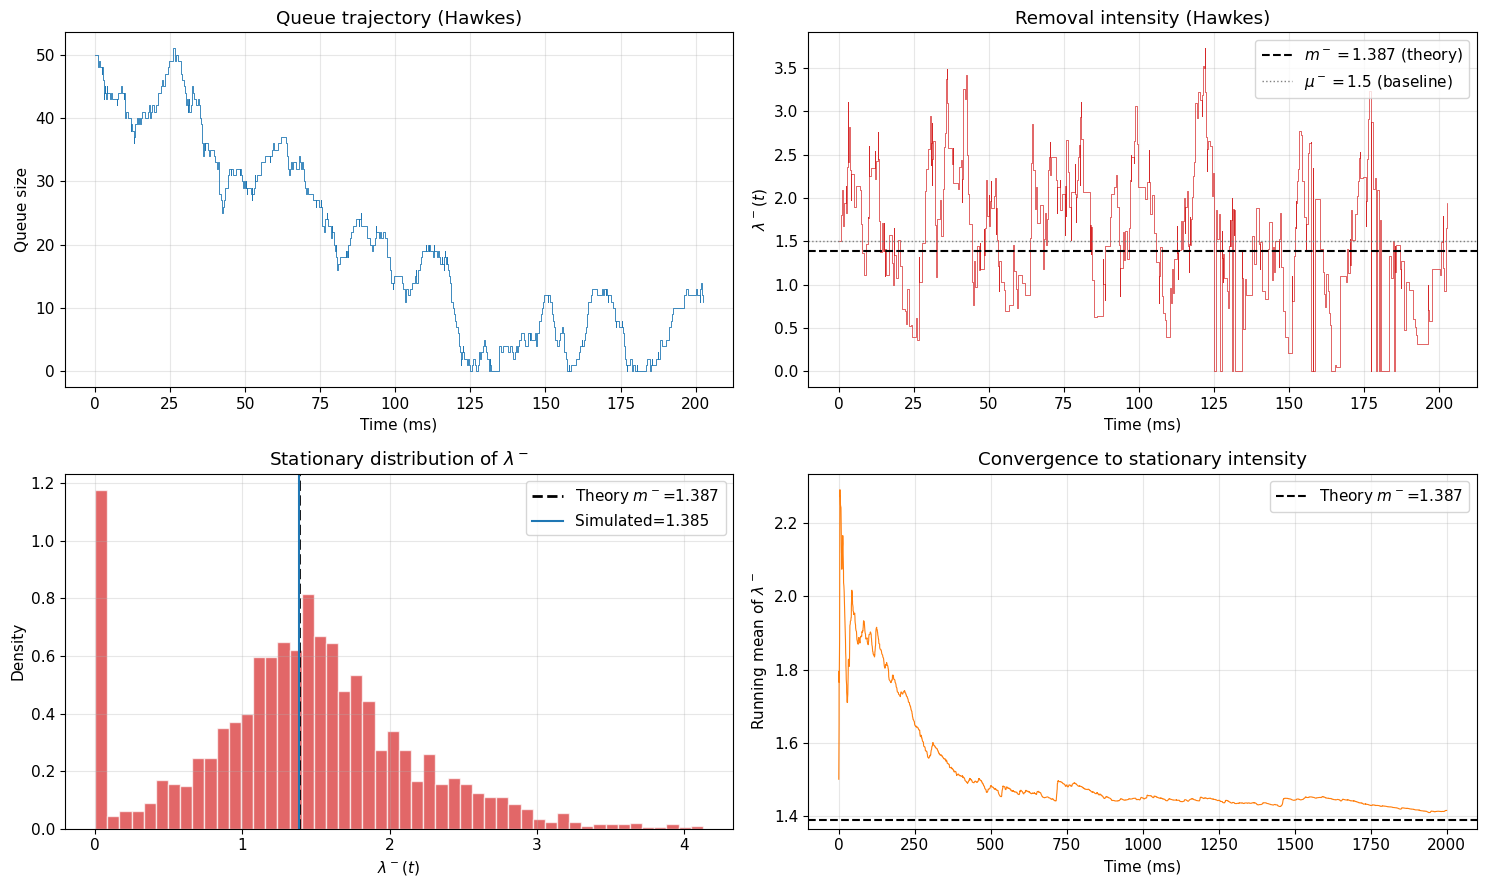

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# ── Top left: queue trajectory ─────────────────────────────────────
ax = axes[0, 0]
t_sub = res_single.times[:500]
q_sub = res_single.queue_path[:500]
ax.step(t_sub, q_sub, where='post', lw=0.6, color='C0')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Queue size')
ax.set_title('Queue trajectory (Hawkes)')

# ── Top right: λ⁻(t) trajectory ────────────────────────────────────
ax = axes[0, 1]
lm_sub = res_single.lambda_minus_path[:500]
ax.step(t_sub, lm_sub, where='post', lw=0.5, color='C3')
ax.axhline(m_theo, ls='--', color='black', lw=1.5, label=f'$m^- = {m_theo:.3f}$ (theory)')
ax.axhline(MU_MINUS, ls=':', color='gray', lw=1, label=f'$\\mu^- = {MU_MINUS}$ (baseline)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('$\\lambda^-(t)$')
ax.set_title('Removal intensity (Hawkes)')
ax.legend()

# ── Bottom left: distribution of λ⁻ ────────────────────────────────
ax = axes[1, 0]
ax.hist(res_single.lambda_minus_path[half:], bins=50, density=True,
        alpha=0.7, color='C3', edgecolor='white')
ax.axvline(m_theo, ls='--', color='black', lw=2, label=f'Theory $m^-$={m_theo:.3f}')
ax.axvline(lam_mean, ls='-', color='C0', lw=1.5, label=f'Simulated={lam_mean:.3f}')
ax.set_xlabel('$\\lambda^-(t)$')
ax.set_ylabel('Density')
ax.set_title('Stationary distribution of $\\lambda^-$')
ax.legend()

# ── Bottom right: running mean ─────────────────────────────────────
ax = axes[1, 1]
cumean = np.cumsum(res_single.lambda_minus_path) / np.arange(1, len(res_single.lambda_minus_path)+1)
ax.plot(res_single.times, cumean, lw=0.8, color='C1')
ax.axhline(m_theo, ls='--', color='black', lw=1.5, label=f'Theory $m^-$={m_theo:.3f}')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Running mean of $\\lambda^-$')
ax.set_title('Convergence to stationary intensity')
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
# ── Monte Carlo estimation of stationary intensity ────────────────
N_est = 50
rng_mc = np.random.default_rng(123)
lam_estimates = []

for _ in range(N_est):
    r = simulate_hawkes_queue(q_init=50, mu_plus=MU_PLUS, mu_minus=MU_MINUS,
                              alpha=ALPHA, beta=BETA, T_max=3000,
                              rng=rng_mc, stop_at_zero=False)
    h = len(r.lambda_minus_path) // 2
    if h > 20:
        lam_estimates.append(r.lambda_minus_path[h:].mean())

arr = np.array(lam_estimates)
ci = 1.96 * arr.std() / np.sqrt(len(arr))
print(f'Estimation from {len(arr)} runs:')
print(f'  ̂λ̄⁻ = {arr.mean():.4f} ± {ci:.4f} (95% CI)')
print(f'  Theory m⁻ = {m_theo:.4f}')
print(f'  In CI? {"✓" if abs(arr.mean() - m_theo) < ci else "✗"}')

Estimation from 50 runs:
  ̂λ̄⁻ = 1.4234 ± 0.0104 (95% CI)
  Theory m⁻ = 1.3875
  In CI? ✗


## B.3 Hawkes vs constant Poisson: comparison

How does the Hawkes excitation change queue dynamics compared to
constant-rate Poisson with the **same** average removal rate?

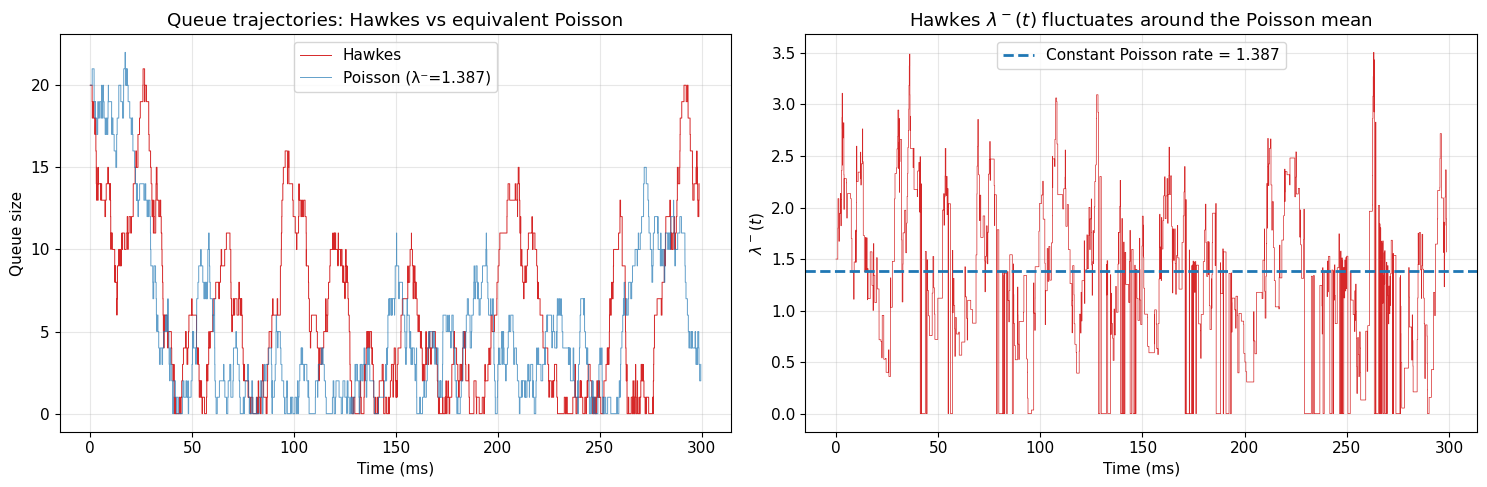

Key observation: Hawkes queue shows BURSTS of activity (clustered events)
while Poisson is uniform. Same average rate, very different dynamics.


In [10]:
# ── Compare: Hawkes vs Poisson with λ⁻ = m⁻ ──────────────────────
rng_cmp = np.random.default_rng(42)

# Hawkes run
res_h = simulate_hawkes_queue(q_init=20, mu_plus=MU_PLUS, mu_minus=MU_MINUS,
                               alpha=ALPHA, beta=BETA, T_max=300,
                               rng=rng_cmp, stop_at_zero=False)

# Poisson run with same mean rates
rng_p = np.random.default_rng(42)
lp_equiv = MU_PLUS
lm_equiv = m_theo  # use the stationary mean
q_poi = 20
t_poi = 0
times_poi, q_path_poi = [0], [q_poi]
while t_poi < 300:
    dt = rng_p.exponential(1.0 / (lp_equiv + lm_equiv))
    t_poi += dt
    if t_poi > 300: break
    q_poi += 1 if rng_p.random() < lp_equiv / (lp_equiv + lm_equiv) else -1
    q_poi = max(0, q_poi)
    times_poi.append(t_poi)
    q_path_poi.append(q_poi)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.step(res_h.times, res_h.queue_path, where='post', lw=0.7, color='C3', label='Hawkes')
ax.step(times_poi, q_path_poi, where='post', lw=0.7, color='C0', alpha=0.7, label=f'Poisson (λ⁻={m_theo:.3f})')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Queue size')
ax.set_title('Queue trajectories: Hawkes vs equivalent Poisson')
ax.legend()

ax = axes[1]
ax.step(res_h.times, res_h.lambda_minus_path, where='post', lw=0.5, color='C3')
ax.axhline(m_theo, ls='--', color='C0', lw=2, label=f'Constant Poisson rate = {m_theo:.3f}')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('$\\lambda^-(t)$')
ax.set_title('Hawkes $\\lambda^-(t)$ fluctuates around the Poisson mean')
ax.legend()

plt.tight_layout()
plt.show()
print('Key observation: Hawkes queue shows BURSTS of activity (clustered events)')
print('while Poisson is uniform. Same average rate, very different dynamics.')

## B.4 Question 1.2.4.2 — Two coupled Hawkes queues

Now the two queues $Q_1$ (ask) and $Q_{-1}$ (bid) are **coupled**:  
events on one queue affect the removal intensity of the other.

Coupling:
- Add to $Q_1$ → $H_1 += \alpha$ (self-excitation), $H_{-1} -= \alpha$ (cross-inhibition)
- Remove from $Q_1$ → $H_1 -= \alpha$, $H_{-1} += \alpha$ (cross-excitation)

**Intuition:** when one side is depleted, the other side's removal accelerates  
(capturing the empirical "rush for liquidity" effect).

In [11]:
# ── Single coupled simulation (no stop at zero) ───────────────────
rng_c = np.random.default_rng(42)
res_c = simulate_coupled_hawkes(
    q1_init=20, q_neg1_init=20,
    mu_plus=MU_PLUS, mu_minus=MU_MINUS,
    alpha=ALPHA, beta=BETA,
    T_max=300.0, rng=rng_c, stop_at_zero=False)

print(f'Coupled simulation: {len(res_c.times)} events in {res_c.times[-1]:.0f}ms')

Coupled simulation: 1498 events in 299ms


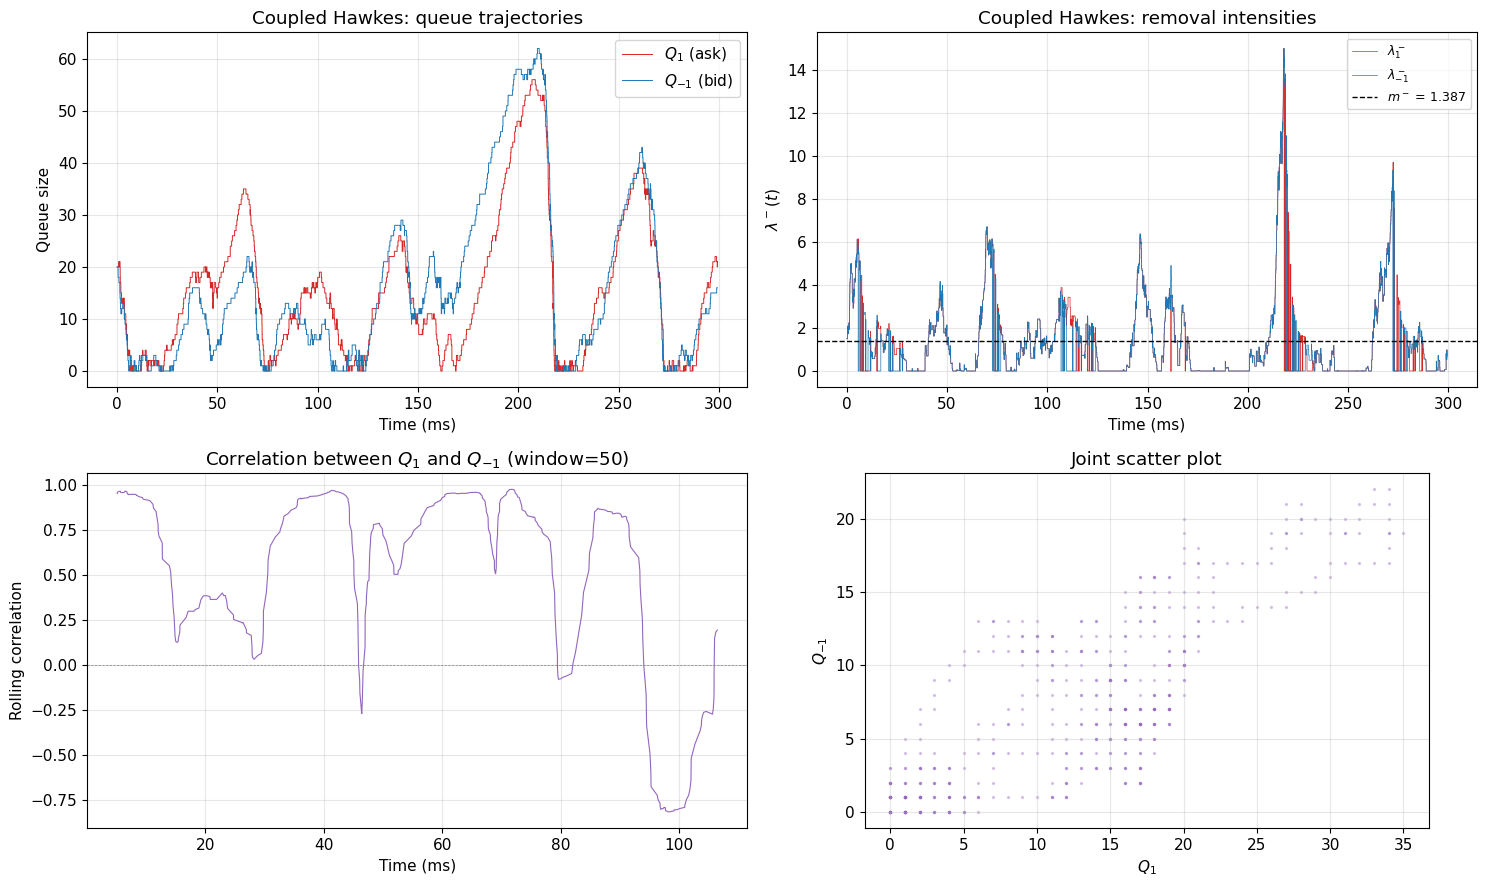

Overall correlation between Q₁ and Q₋₁: 0.885
→ The coupling creates correlation between the two queues!
   (independent Poisson model would give correlation ≈ 0)


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# ── Top: queue trajectories ─────────────────────────────────────────
ax = axes[0, 0]
ax.step(res_c.times, res_c.q1_path, where='post', lw=0.7, color='C3', label='$Q_1$ (ask)')
ax.step(res_c.times, res_c.q_neg1_path, where='post', lw=0.7, color='C0', label='$Q_{-1}$ (bid)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Queue size')
ax.set_title('Coupled Hawkes: queue trajectories')
ax.legend()

# ── Top right: intensities ──────────────────────────────────────────
ax = axes[0, 1]
ax.step(res_c.times, res_c.lam_minus_1_path, where='post', lw=0.5, color='C3', label='$\\lambda^-_1$')
ax.step(res_c.times, res_c.lam_minus_neg1_path, where='post', lw=0.5, color='C0', label='$\\lambda^-_{-1}$')
ax.axhline(m_theo, ls='--', color='black', lw=1, label=f'$m^-$ = {m_theo:.3f}')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('$\\lambda^-(t)$')
ax.set_title('Coupled Hawkes: removal intensities')
ax.legend(fontsize=9)

# ── Bottom left: correlation between Q1 and Q-1 ────────────────────
ax = axes[1, 0]
# Compute rolling correlation
n_pts = min(len(res_c.q1_path), 500)
q1_s = res_c.q1_path[:n_pts]
qn1_s = res_c.q_neg1_path[:n_pts]
window = 50
if len(q1_s) > window:
    corrs = [np.corrcoef(q1_s[max(0,i-window):i], qn1_s[max(0,i-window):i])[0,1]
             for i in range(window, len(q1_s))]
    ax.plot(res_c.times[window:n_pts], corrs, lw=0.8, color='C4')
    ax.axhline(0, ls='--', color='gray', lw=0.5)
    ax.set_ylabel('Rolling correlation')
    ax.set_title(f'Correlation between $Q_1$ and $Q_{{-1}}$ (window={window})')
ax.set_xlabel('Time (ms)')

# ── Bottom right: scatter Q1 vs Q-1 ────────────────────────────────
ax = axes[1, 1]
ax.scatter(res_c.q1_path[:n_pts], res_c.q_neg1_path[:n_pts], s=2, alpha=0.3, color='C4')
ax.set_xlabel('$Q_1$')
ax.set_ylabel('$Q_{-1}$')
ax.set_title('Joint scatter plot')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

overall_corr = np.corrcoef(res_c.q1_path, res_c.q_neg1_path)[0, 1]
print(f'Overall correlation between Q₁ and Q₋₁: {overall_corr:.3f}')
print('→ The coupling creates correlation between the two queues!')
print('   (independent Poisson model would give correlation ≈ 0)')

## B.5 Hitting time comparison: coupled Hawkes vs independent Poisson

In [13]:
# ── Batch: hitting times for coupled Hawkes ───────────────────────
N_batch = 1000
rng_batch = np.random.default_rng(42)

ht_hawkes = []
which_hawkes = []
for _ in range(N_batch):
    r = simulate_coupled_hawkes(
        10, 10, MU_PLUS, MU_MINUS, ALPHA, BETA,
        T_max=5000, rng=rng_batch, stop_at_zero=True)
    if r.hit_zero:
        ht_hawkes.append(r.hitting_time)
        which_hawkes.append(r.which_hit)

ht_hawkes = np.array(ht_hawkes)
which_hawkes = np.array(which_hawkes)

# Independent Poisson with same effective rates
ht_poisson = batch_hitting_times(
    N_batch, 10, 10, MU_PLUS, m_theo, seed=42)

print(f'=== Hitting time comparison (Q₁(0) = Q₋₁(0) = 10) ===')
print(f'\nCoupled Hawkes ({len(ht_hawkes)}/{N_batch} hit zero):')
print(f'  E[T] = {ht_hawkes.mean():.1f} ms')
print(f'  Std  = {ht_hawkes.std():.1f} ms')
print(f'  P(Q₁ first) = {(which_hawkes == 1).mean():.3f}')
print(f'\nIndependent Poisson (λ⁻ = m⁻ = {m_theo:.3f}):')
print(f'  E[T] = {ht_poisson["mean_T"]:.1f} ms')
print(f'  Std  = {ht_poisson["std_T"]:.1f} ms')
print(f'  P(Q₁ first) = {ht_poisson["prob_q1_first"]:.3f}')

=== Hitting time comparison (Q₁(0) = Q₋₁(0) = 10) ===

Coupled Hawkes (1000/1000 hit zero):
  E[T] = 15.2 ms
  Std  = 18.9 ms
  P(Q₁ first) = 0.519

Independent Poisson (λ⁻ = m⁻ = 1.387):
  E[T] = 26.8 ms
  Std  = 25.0 ms
  P(Q₁ first) = 0.477


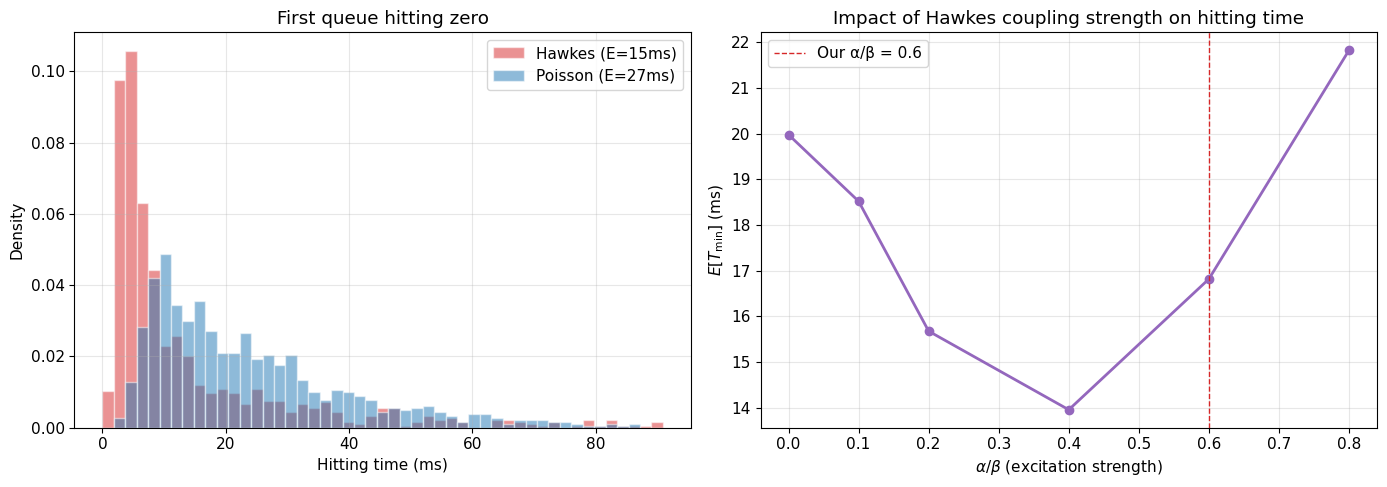

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: hitting time distributions
ax = axes[0]
t_max_plot = min(np.percentile(ht_hawkes, 99), np.percentile(ht_poisson['hitting_times'], 99))
bins = np.linspace(0, t_max_plot, 50)
ax.hist(ht_hawkes, bins=bins, density=True, alpha=0.5, color='C3',
        edgecolor='white', label=f'Hawkes (E={ht_hawkes.mean():.0f}ms)')
ax.hist(ht_poisson['hitting_times'], bins=bins, density=True, alpha=0.5, color='C0',
        edgecolor='white', label=f'Poisson (E={ht_poisson["mean_T"]:.0f}ms)')
ax.set_xlabel('Hitting time (ms)')
ax.set_ylabel('Density')
ax.set_title('First queue hitting zero')
ax.legend()

# Right: sensitivity to α/β
ax = axes[1]
ratios = [0.0, 0.1, 0.2, 0.4, 0.6, 0.8]
mean_Ts = []
for r in ratios:
    a_val = r * BETA
    rng_s = np.random.default_rng(42)
    ts = []
    for _ in range(300):
        res = simulate_coupled_hawkes(
            10, 10, MU_PLUS, MU_MINUS, a_val, BETA,
            T_max=5000, rng=rng_s, stop_at_zero=True)
        if res.hit_zero:
            ts.append(res.hitting_time)
    mean_Ts.append(np.mean(ts) if ts else np.nan)

ax.plot(ratios, mean_Ts, 'o-', color='C4', lw=2, ms=6)
ax.set_xlabel('$\\alpha / \\beta$ (excitation strength)')
ax.set_ylabel('$E[T_{\\min}]$ (ms)')
ax.set_title('Impact of Hawkes coupling strength on hitting time')
ax.axvline(ALPHA/BETA, ls='--', color='C3', lw=1, label=f'Our α/β = {ALPHA/BETA}')
ax.legend()

plt.tight_layout()
plt.show()

## B.6 Parameter sensitivity: stationarity boundary

The stationarity condition is $\alpha/\beta < 1$. What happens as we approach this boundary?

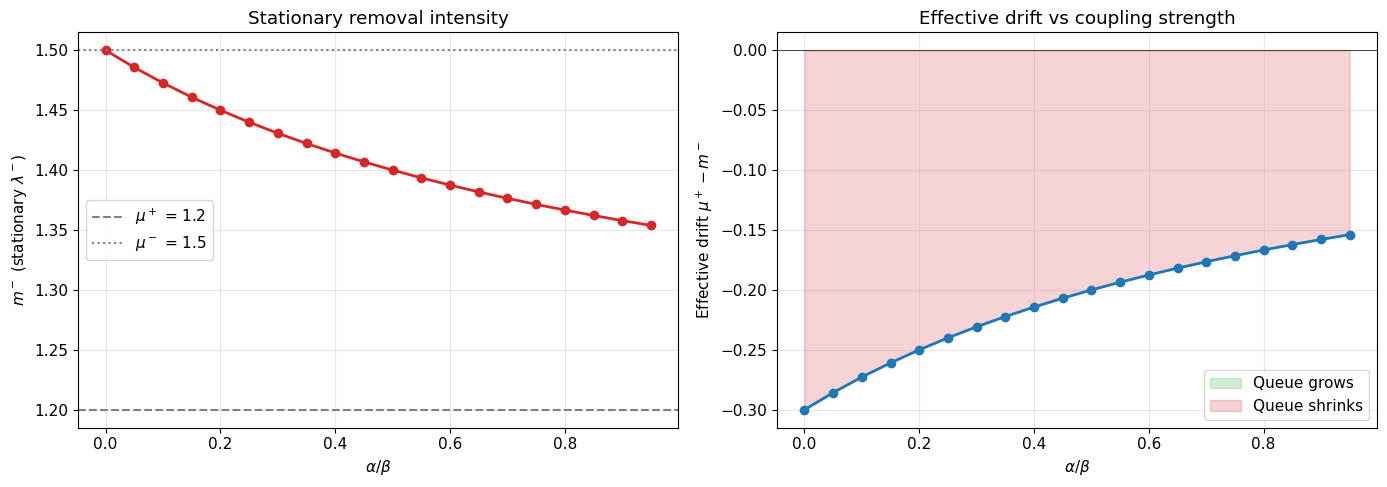

When μ⁺ ≠ μ⁻, the drift μ⁺ - m⁻ → μ⁺ - (μ⁺+μ⁻)/2 = (μ⁺-μ⁻)/2 as α/β → 1
  Here: (μ⁺-μ⁻)/2 = -0.15000000000000002 > 0
  The Hawkes coupling REDUCES the effective drift but never flips its sign (for these params).


In [15]:
# ── Stationary intensity as function of α/β ───────────────────────
ratios_full = np.linspace(0, 0.95, 20)
m_values = [(MU_MINUS + r*MU_PLUS)/(1+r) for r in ratios_full]
drift_values = [MU_PLUS - m for m in m_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ratios_full, m_values, 'o-', color='C3', lw=2)
ax.axhline(MU_PLUS, ls='--', color='gray', label=f'$\\mu^+$ = {MU_PLUS}')
ax.axhline(MU_MINUS, ls=':', color='gray', label=f'$\\mu^-$ = {MU_MINUS}')
ax.set_xlabel('$\\alpha / \\beta$')
ax.set_ylabel('$m^-$ (stationary $\\lambda^-$)')
ax.set_title('Stationary removal intensity')
ax.legend()

ax = axes[1]
ax.plot(ratios_full, drift_values, 'o-', color='C0', lw=2)
ax.axhline(0, ls='-', color='black', lw=0.5)
ax.fill_between(ratios_full, drift_values, 0,
                where=np.array(drift_values) > 0, alpha=0.2, color='C2', label='Queue grows')
ax.fill_between(ratios_full, drift_values, 0,
                where=np.array(drift_values) < 0, alpha=0.2, color='C3', label='Queue shrinks')
ax.set_xlabel('$\\alpha / \\beta$')
ax.set_ylabel('Effective drift $\\mu^+ - m^-$')
ax.set_title('Effective drift vs coupling strength')
ax.legend()

plt.tight_layout()
plt.show()

# Find critical α/β where drift = 0
# μ⁺ = m⁻ → μ⁺(1+r) = μ⁻ + rμ⁺ → μ⁺ = μ⁻
# This happens only when μ⁺ = μ⁻! Otherwise drift is always nonzero.
r_crit = (MU_PLUS - MU_MINUS) / (MU_PLUS - MU_PLUS)  if MU_PLUS != MU_PLUS else None
print(f'When μ⁺ ≠ μ⁻, the drift μ⁺ - m⁻ → μ⁺ - (μ⁺+μ⁻)/2 = (μ⁺-μ⁻)/2 as α/β → 1')
print(f'  Here: (μ⁺-μ⁻)/2 = {(MU_PLUS-MU_MINUS)/2} > 0')
print(f'  The Hawkes coupling REDUCES the effective drift but never flips its sign (for these params).')

---
## Summary

| Topic | Key Result |
|-------|------------|
| **Section 2.1** | Discrete and BM agree when $\mu \leq 0$ ($P = 1$). When $\mu > 0$, both give $P \propto e^{-ca}$ but with different $c$: $-\ln\rho$ vs $2\mu/\sigma^2$. BM ignores lattice structure. |
| **Q 1.2.4.1** | Single Hawkes queue: $\hat{\bar\lambda}^- \approx m^- = \frac{\mu^- + (\alpha/\beta)\mu^+}{1 + \alpha/\beta}$, validated by MC. |
| **Q 1.2.4.2** | Coupled Hawkes creates **correlation** between $Q_1$ and $Q_{-1}$ (absent in independent model) and **event clustering** (bursts of activity). |
| **Stationarity** | Requires $\alpha/\beta < 1$. As coupling increases, $m^-$ approaches $(\mu^+ + \mu^-)/2$. |